In [34]:
%cd ~/repos/foo_cleaned

/rds/general/user/ap125/home/repos/foo_cleaned


In [35]:
import os
#os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".20"

In [36]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import functions
import pybamm
import numpy as np
from tqdm import trange
import optuna

In [37]:
import jax
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())

All devices: [CudaDevice(id=0)]
Default backend: gpu


In [38]:
from FNO import *

In [39]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [40]:
# family = "CC_"
# id  = "8"
# path = "data/spm/diff_D/"
# train_data = np.load(path + "train/" + family + "281600" + ".npz")
# test_data = np.load(path + "test/" + family + "28160" + ".npz")

In [41]:
family = "CC"
N_total = 110
data = np.load(f"data/{family}_{N_total}.npz")

In [42]:
rng      = np.random.default_rng(seed=42)
perm     = rng.permutation(N_total)

# 3 ── choose split point ---------------------------------------------------
test_size = int(0.10 * N_total)                   # 10 %
test_idx  = perm[:test_size]
train_idx = perm[test_size:]

# 4 ── slice every array ----------------------------------------------------
train_data = {k: v[train_idx] for k, v in data.items()}
test_data  = {k: v[test_idx]  for k, v in data.items()}

In [43]:
train_data.keys()

dict_keys(['soc', 'Dan', 'Dca', 'cn_anode', 'c0_anode', 'cn_cathode', 'c0_cathode', 'current'])

In [44]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["cn_anode"])
test_cn = np.array(test_data["cn_anode"])

train_c0 = np.array(train_data["c0_anode"])
test_c0 = np.array(test_data["c0_anode"])

train_D = np.array(train_data["Dan"])
test_D = np.array(test_data["Dan"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [45]:
train_ratio = train_c0.shape[0] / train_D.shape[0]
test_ratio = test_c0.shape[0] / test_D.shape[0]
if not (train_ratio+test_ratio).is_integer():
    raise ValueError(f"Ratio must be integer but got {train_ratio} and {test_ratio}")


In [46]:
train_D = np.repeat(train_D, int(train_ratio), axis=0)
test_D = np.repeat(test_D, int(test_ratio), axis = 0)

In [47]:
def scale_the_D(D, lower=-15, upper=-12):
    return 2*(D-lower)/(upper-lower) - 1

In [48]:
train_D = scale_the_D(train_D)
test_D = scale_the_D(test_D)

In [ ]:
# Assume these hyperparameters
k_modes = 7
fno_depth = 6
hidden_channels = 64
output_channels = 1
param_channels = 50
cape_hidden_size = 32

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)
dummy_D = jax.random.normal(key_main, (1,1))

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar


# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)
# Broadcast Ds_padded (24,) to (24, 85)


# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
# input_tensor = jnp.stack([I_2D, c0_2D, Ds_2D], axis=-1)   # (24,85,4)
input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

model = CAPE_FNO(k_modes=k_modes, input_channels= input_tensor.shape[-1], fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor, dummy_D)

# Forward pass
out = model.apply(params, input_tensor, dummy_D)
print("Input shape:", input_tensor.shape)  # should be (1,24,85,5)
print("Output shape:", out.shape)  # should be (1,24,85,1)


x before cape: (1, 24, 85, 64)
(1, 64)
(1, 1, 1, 64)
(1, 24, 85, 64)
(1, 24, 85, 64)
x after cape: (1, 24, 85, 64)
x before cape: (1, 24, 85, 64)
(1, 64)
(1, 1, 1, 64)
(1, 24, 85, 64)
(1, 24, 85, 64)
x after cape: (1, 24, 85, 64)
Input shape: (1, 24, 85, 4)
Output shape: (1, 24, 85, 1)


In [51]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = np.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =np.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = np.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = np.zeros((num_samples, H, W, 4))
    Y = np.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return np.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return np.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)



    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = np.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = np.tile(c0_padded[:, :, None], (1, 1, W))


    # R,T are the same for all samples, just expand
    R_3D = np.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = np.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)


    # Stack channels: (num_samples,24,85,4)
    X = np.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)
    # X = np.stack([I_2D, c0_2D, Ds_2D], axis=-1) #Here we try to see if it works without the grid information

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = np.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [52]:
def data_loader(X: np.ndarray, D, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    """
    A simple data loader that yields batches of preprocessed FNO data.
    
    Parameters
    ----------
    X : jnp.ndarray
        Preprocessed input data of shape (num_samples, 24,85,4).
    Y : jnp.ndarray
        Preprocessed target data of shape (num_samples, 24,85,1).
    batch_size : int
        Number of samples per batch.
    shuffle : bool
        Whether to shuffle the dataset before yielding batches.

    Yields
    ------
    (X_batch, Y_batch) : tuple of jnp.ndarray
        X_batch : (batch_size, 24,85,4)
        Y_batch : (batch_size, 24,85,1)
    """
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        batch_indices = indices[start_idx:start_idx+batch_size]
        yield X[batch_indices],D[batch_indices], Y[batch_indices]



In [53]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [54]:
def loss_fn(params, X_batch, D_batch, Y_batch):
    preds = model.apply(params, X_batch, D_batch)  # (batch_size, H, W, 1)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [55]:
#@jax.jit
def train_step(params, opt_state, X_batch, D_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch,D_batch, Y_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [56]:
X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

In [57]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (99, 24, 85, 4) dtype: float64
Y_train shape: (99, 24, 85, 1) dtype: float64


In [58]:
Y_train[0,2:22,5:80,:].squeeze()

array([[0.65155298, 0.66451905, 0.67848612, ..., 0.34332162, 0.35842963,
        0.373433  ],
       [0.65155298, 0.66453247, 0.67849881, ..., 0.34333574, 0.35844378,
        0.37344692],
       [0.65155298, 0.66455931, 0.67852419, ..., 0.34336398, 0.35847206,
        0.37347477],
       ...,
       [0.65155298, 0.66657018, 0.68042273, ..., 0.34548362, 0.36059365,
        0.37556204],
       [0.65155298, 0.66681111, 0.68064987, ..., 0.34573817, 0.36084823,
        0.37581231],
       [0.65155298, 0.66706532, 0.68088947, ..., 0.34600691, 0.36111695,
        0.37607642]], shape=(20, 75))

In [59]:
# X_train = X_train[:22000]
# Y_train = Y_train[:22000]

# X_test = X_test[:2200]
# Y_test = Y_test[:2200]

In [60]:
check()

Geiloo


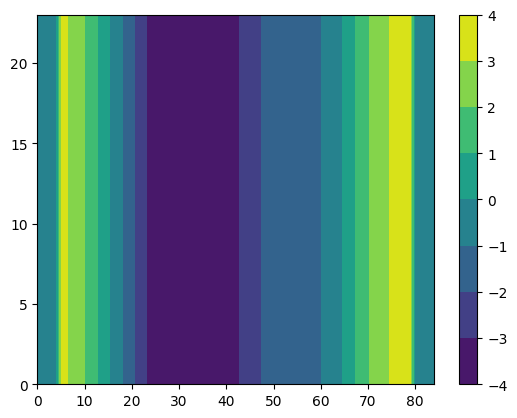

In [61]:
plt.contourf(X_train[0,:,:,0])
plt.colorbar()

In [62]:
X_train[0,:,:,2]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(24, 85))

In [63]:
# X_train = X_train[2000:30000]
# Y_train = Y_train[2000:30000]

In [64]:
import jax
import optax
import math

def create_cosine_schedule_with_warmup(
    warmup_steps: int,
    peak_lr: float,
    total_steps: int,
    end_lr: float = 0.0
):
    """Returns an Optax schedule: warmup -> cosine decay."""
    
    def schedule_fn(step):
        # Phase 1: Warmup
        # linearly go from 0 to peak_lr over warmup_steps
        lr = jax.lax.cond(
            step < warmup_steps,
            lambda s: peak_lr * (s / warmup_steps),
            lambda s: 0.0,
            step
        )
        
        # Phase 2: Cosine decay
        # after warmup, go from peak_lr to end_lr via half-cosine
        def decay_fn(s):
            progress = (s - warmup_steps) / float(total_steps - warmup_steps)
            # clamp progress between 0 and 1
            progress = jnp.clip(progress, 0.0, 1.0)
            cosine = 0.5 * (1.0 + jnp.cos(jnp.pi * progress))
            return end_lr + (peak_lr - end_lr) * cosine
        
        lr = jax.lax.cond(
            step >= warmup_steps,
            decay_fn,
            lambda s: lr,
            step
        )
        return lr
    
    return schedule_fn

# Suppose:
warmup_steps = 11734           # ~1 epoch, if 11,734 steps is an epoch
peak_lr = 1e-2                  # try bigger than your current 4e-3
total_steps = 25 * 11734        # ~293,350
end_lr = 1e-4                   # final LR

scheduler = create_cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

optimizer = optax.adam(scheduler)
# Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

# Setup optimizer (Adam)

# learning_rate = 4e-3
# optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


In [65]:
X_train.shape

(99, 24, 85, 4)

In [66]:
num_epochs = 25
pbar = trange(num_epochs, desc="Training")

batch_size = 20

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, Y_batch in data_loader(X_train, train_D, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch),jnp.array(D_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
        if count % 1000 == 0:
            print()
    
    print(f"Training Iterations per Epoch: {count}")

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, Y_batch in data_loader(X_test,test_D, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Training:   0%|          | 0/25 [00:00<?, ?it/s]

x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (19, 24, 85, 64)
(19, 64)
(19, 1, 1, 64)
(19, 24, 85, 64)
(19, 24, 85, 64)
x after cape: (19, 24, 85, 64)
Training Iterations per Epoch: 5
x before cape: (11, 24, 85, 64)
(11, 64)
(11, 1, 1, 64)
(11, 24, 85, 64)
(11, 24, 85, 64)
x after cape: (11, 24, 85, 64)


Epoch 1/25 | Train Loss: 0.9288 | Test Loss: 0.9446:   4%|▍         | 1/25 [00:27<10:48, 27.01s/it]

x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (19, 24, 85, 64)
(19, 64)
(19, 1, 1, 64)
(19, 24, 85, 64)
(19, 24, 85, 64)
x after cape: (19, 24, 85, 64)


Epoch 2/25 | Train Loss: 0.9295 | Test Loss: 0.9403:   8%|▊         | 2/25 [00:29<04:45, 12.39s/it]

...

Training Iterations per Epoch: 5
x before cape: (11, 24, 85, 64)
(11, 64)
(11, 1, 1, 64)
(11, 24, 85, 64)
(11, 24, 85, 64)
x after cape: (11, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (19, 24, 85, 64)
(19, 64)
(19, 1, 1, 64)
(19, 24, 85, 64)
(19, 24, 85, 64)
x after cape: (19, 24, 85, 64)


Epoch 24/25 | Train Loss: 0.3236 | Test Loss: 0.3336:  96%|█████████▌| 24/25 [01:18<00:02,  2.23s/it]

Training Iterations per Epoch: 5
x before cape: (11, 24, 85, 64)
(11, 64)
(11, 1, 1, 64)
(11, 24, 85, 64)
(11, 24, 85, 64)
x after cape: (11, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (20, 24, 85, 64)
(20, 64)
(20, 1, 1, 64)
(20, 24, 85, 64)
(20, 24, 85, 64)
x after cape: (20, 24, 85, 64)
x before cape: (19, 24, 85, 64)
(19, 64)
(19, 1, 1, 64)
(19, 24, 85, 64)
(19, 24, 85, 64)
x after cape: (19, 24, 85, 64)


Epoch 25/25 | Train Loss: 0.2787 | Test Loss: 0.3079: 100%|██████████| 25/25 [01:20<00:00,  3.21s/it]

Training Iterations per Epoch: 5
x before cape: (11, 24, 85, 64)
(11, 64)
(11, 1, 1, 64)
(11, 24, 85, 64)
(11, 24, 85, 64)
x after cape: (11, 24, 85, 64)


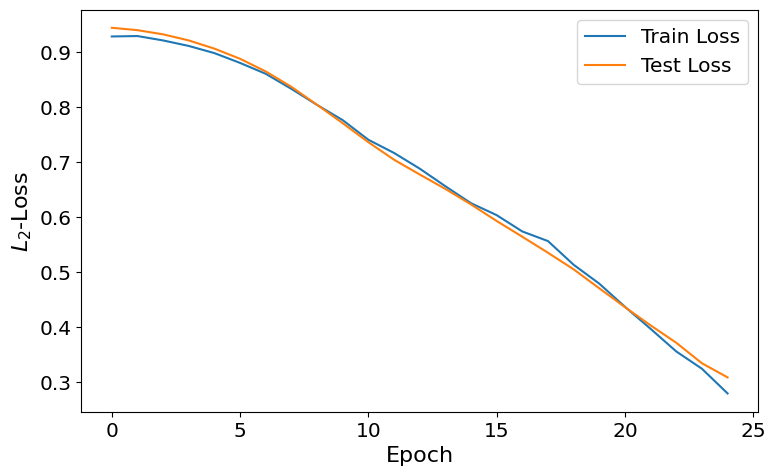

In [67]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [68]:
train_idx = np.random.randint(2, 22000)
test_idx = np.random.randint(2, 2200)

In [69]:
X_train[3][None,...].shape

(1, 24, 85, 4)

In [70]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])

H_orig = 20
W_orig = 75
padding_r = 2
padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)


IndexError: index 11410 is out of bounds for axis 0 with size 99

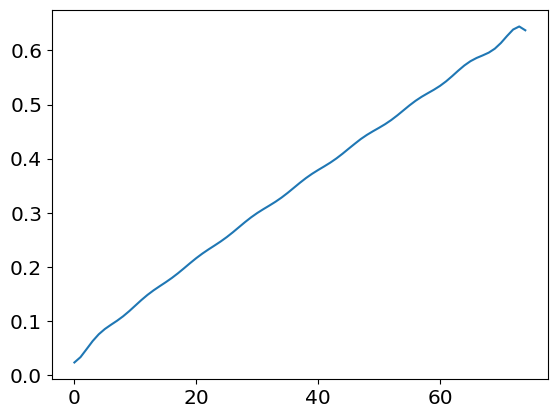

In [ ]:
plt.plot(c_train_pred_reshaped[-1,:])

In [ ]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [ ]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


In [ ]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


In [ ]:
c_train_pred_scaled[:,:].shape
#c_train_true_scaled[20,:]

(20, 75)

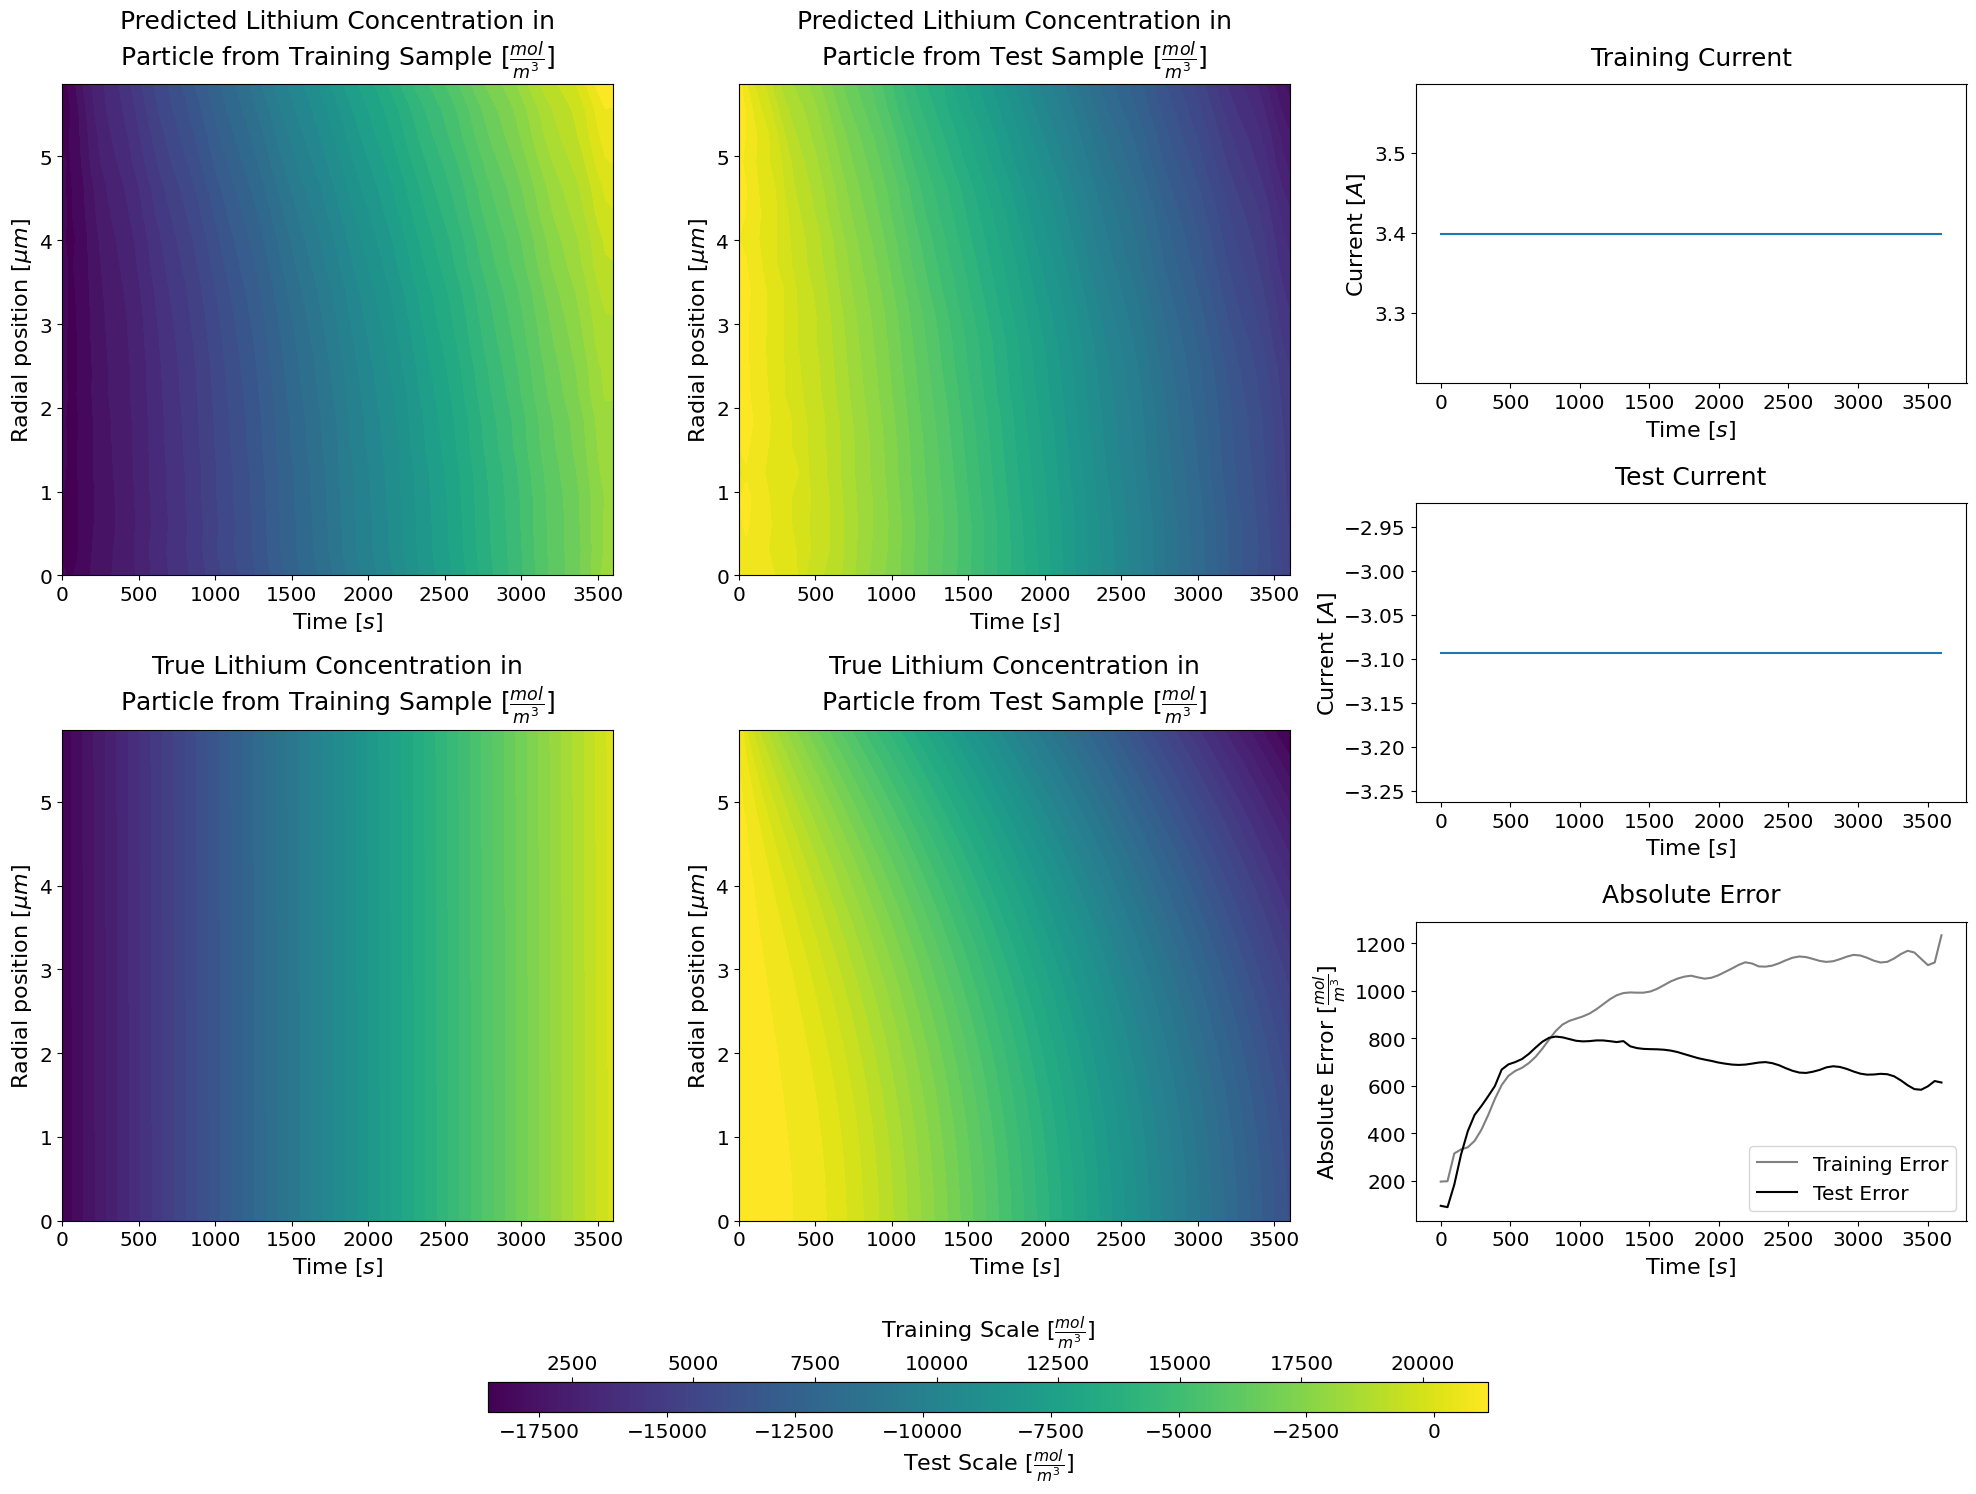

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [ ]:
train_c0[train_idx]

array([0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473])

In [ ]:
test_c0[test_idx]

array([0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473])

In [ ]:
import os
import flax.serialization
from datetime import datetime

In [ ]:
# def save_model_params(params, directory="./trained_models", prefix = "anode"):
#     """Serialize and save model params with a timestamped filename."""
#     os.makedirs(directory, exist_ok=True)
#     # Create a unique timestamp string, e.g. "2025-03-06_14-20-59"
#     timestamp_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
#     # Construct filename, e.g. "./checkpoints/model_params_2025-03-06_14-20-59.msgpack"
#     filename = os.path.join(directory, f"{prefix}_{timestamp_str}.msgpack")

#     # Convert params PyTree to a bytes object
#     param_bytes = flax.serialization.to_bytes(params)

#     # Write to disk
#     with open(filename, "wb") as f:
#         f.write(param_bytes)

#     print(f"Saved model parameters to {filename}")
#     return filename

In [ ]:
filename = functions.save_model_params(params, directory = "./trained_models/cape_fno", family = family)

Saved model parameters to ./trained_models/diff_D/anode_CC__2025-04-28_20-40-30.msgpack


In [ ]:
import gc
# del model
# del params
del X_train, Y_train, X_test, Y_test

#jax.clear_compilation_cache()
gc.collect()


6203

In [ ]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["cn_cathode"])
test_cn = np.array(test_data["cn_cathode"])

train_c0 = np.array(train_data["c0_cathode"])
test_c0 = np.array(test_data["c0_cathode"])

train_D = np.array(train_data["Dca"])
test_D = np.array(test_data["Dca"])

train_D = np.repeat(train_D, int(train_ratio), axis=0)
test_D = np.repeat(test_D, int(test_ratio), axis = 0)

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

(281600, 24, 85)
(281600, 24, 85)
(28160, 24, 85)
(28160, 24, 85)


In [ ]:
train_D = scale_the_D(train_D)
test_D = scale_the_D(test_D)

In [ ]:
# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
out = model.apply(params, input_tensor)
print("Output shape:", out.shape)  # should be (1,24,85,1)

Output shape: (1, 24, 85, 1)


In [ ]:
pbar = trange(num_epochs, desc="Training")

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, Y_batch in data_loader(X_train, train_D, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch),jnp.array(D_batch) , jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
        if count % 1000 == 0:
            print()
    
    print(f"Training Iterations per Epoch: {count}")

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, Y_batch in data_loader(X_test,test_D, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Training:   0%|          | 0/25 [00:00<?, ?it/s]


ValueError: Dict key mismatch; expected keys: ['Dense_0', 'Dense_1', 'Dense_2', 'Dense_3', 'Dense_4', 'Dense_5', 'Dense_6', 'Dense_7', 'FourierLayer_0', 'FourierLayer_1', 'FourierLayer_2', 'FourierLayer_3', 'FourierLayer_4', 'FourierLayer_5']; dict: {'Dense_0': {'bias': Traced<ShapedArray(float32[50])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[1,50])>with<DynamicJaxprTrace>}, 'Dense_1': {'bias': Traced<ShapedArray(float32[50])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[50,50])>with<DynamicJaxprTrace>}, 'Dense_2': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[5,64])>with<DynamicJaxprTrace>}, 'Dense_3': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[64,64])>with<DynamicJaxprTrace>}, 'Dense_4': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[64,64])>with<DynamicJaxprTrace>}, 'Dense_5': 

In [ ]:
filename = functions.save_model_params(params, directory = "./trained_models/cape_fno", prefix = "cathode", family = family)

Saved model parameters to ./trained_models/diff_D/cathode_CC__2025-03-24_16-22-03.msgpack


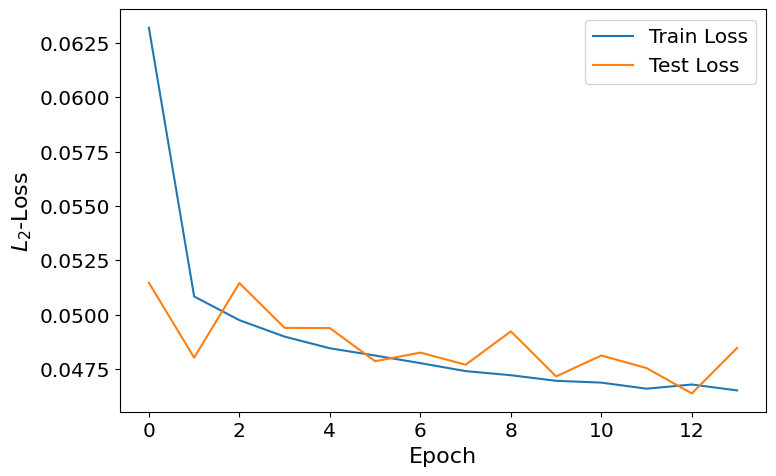

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [ ]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])

# H_orig = 20
# W_orig = 75
# padding_r = 2
# padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)

In [ ]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [ ]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

In [ ]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


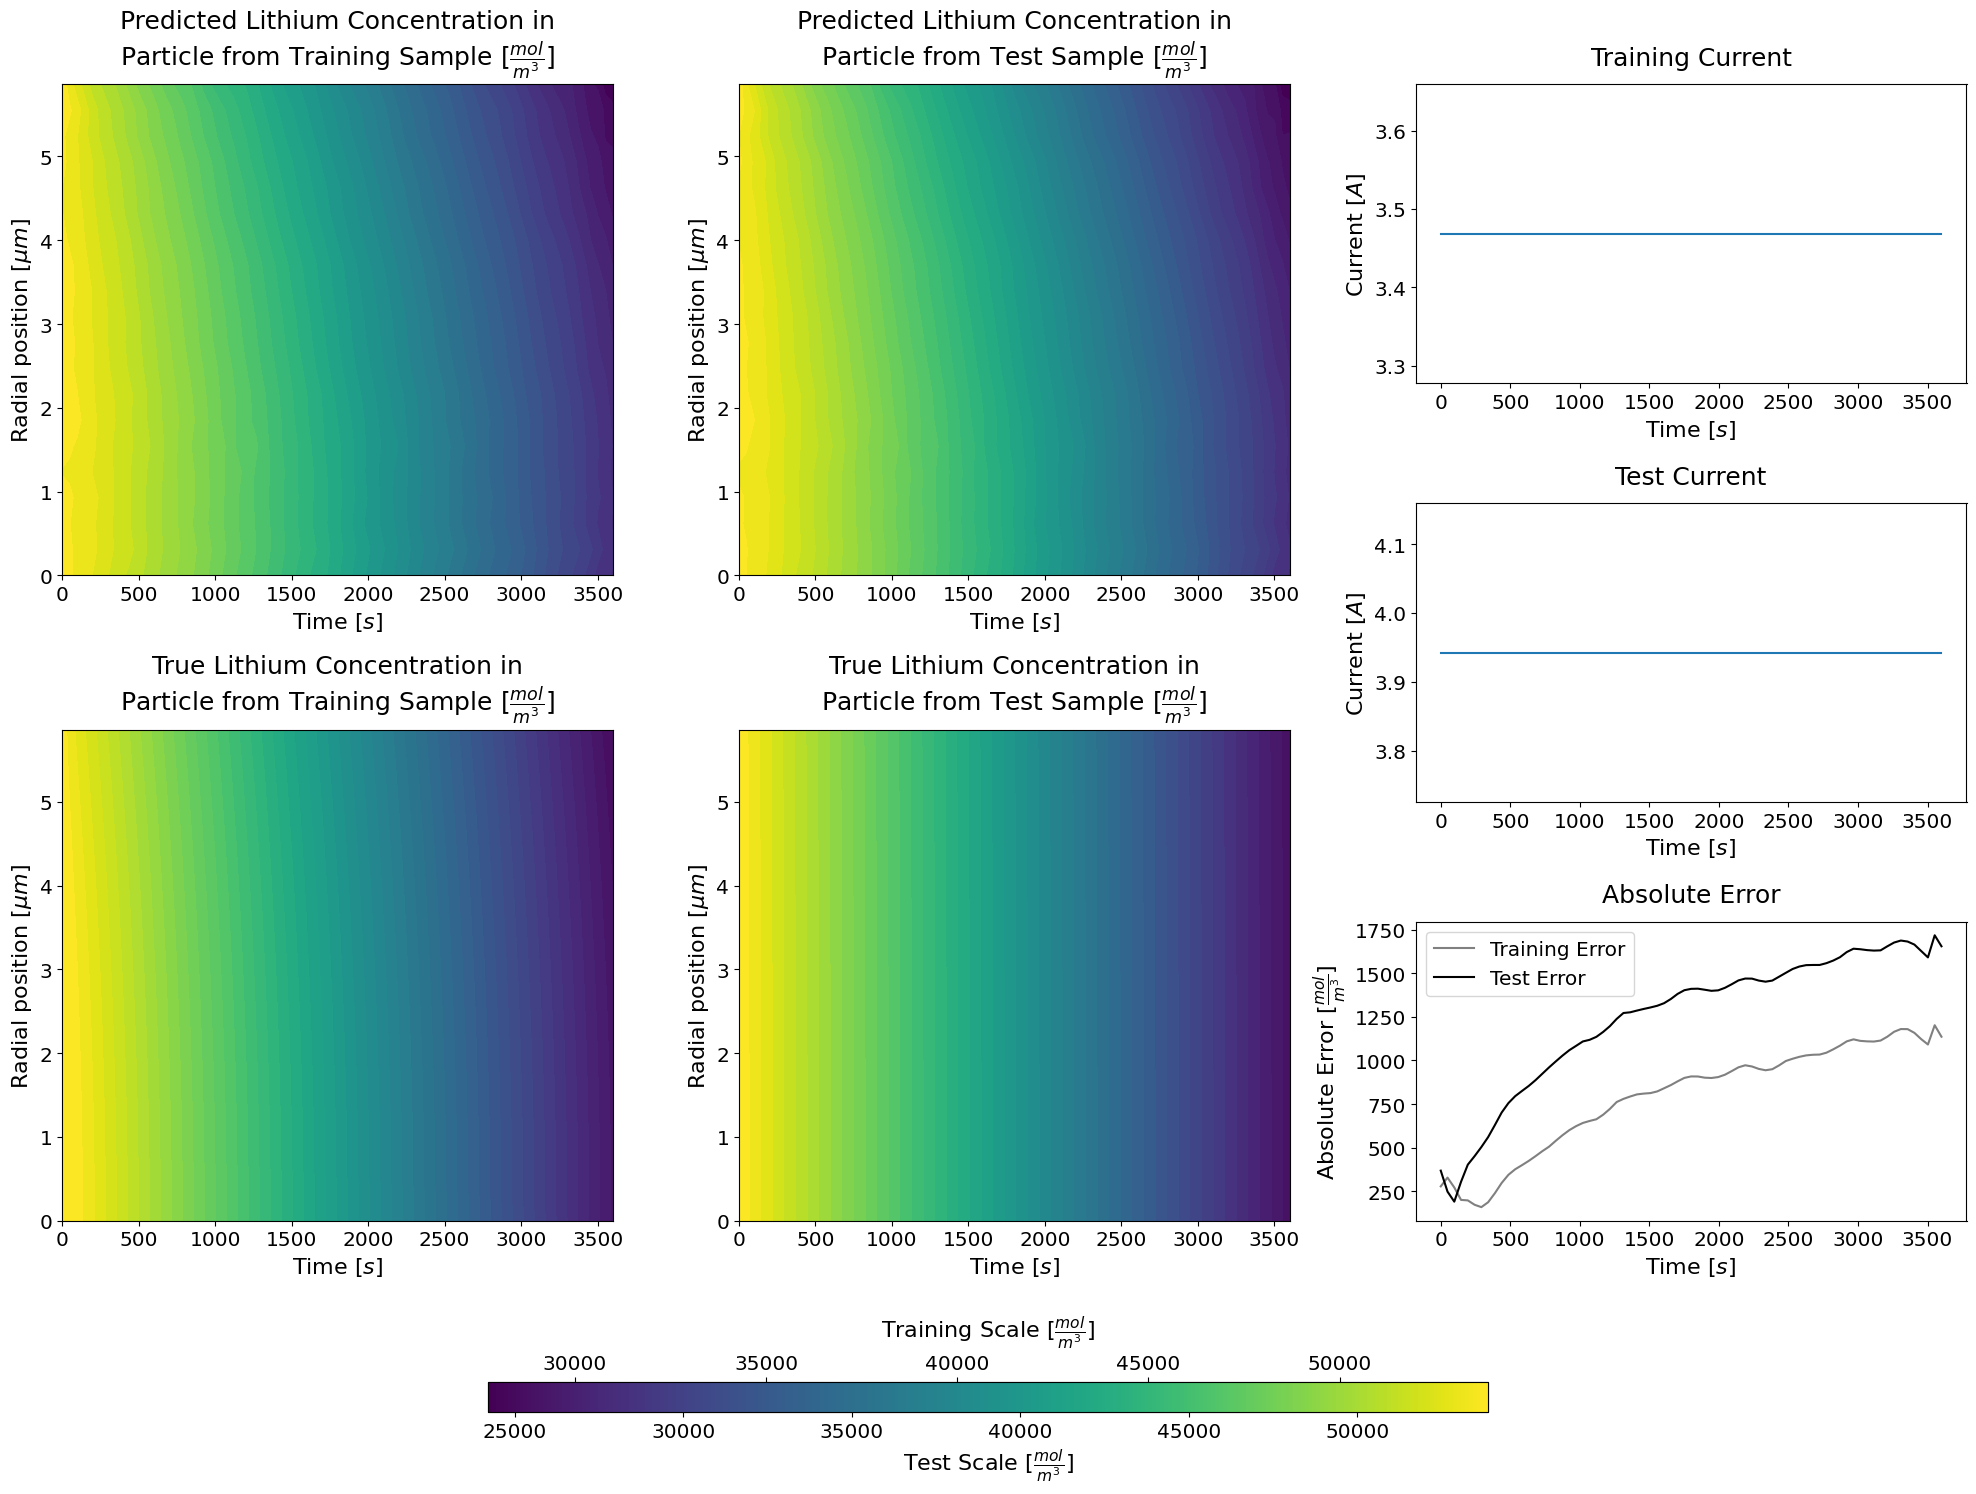

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()